<a href="https://colab.research.google.com/github/Abdallah-Osama-cpp/heart-disease-prediction/blob/main/Copy_of_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
df = pd.read_csv('train_data.csv') # train data
dt = pd.read_csv('test_data.csv')  # test data

**DATA EXPLORE**

In [145]:
df.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
5,6,65.0,Female,4,120,177,0,0,140,0,0.4,1,0,7,Private,formerly smoked,No
6,7,56.0,Female,3,130,256,1,2,142,1,0.6,2,1,6,Private,never smoked,Yes
7,8,59.0,Female,4,110,239,0,2,142,1,1.2,2,1,7,Private,never smoked,Yes
8,9,60.0,Female,4,140,293,0,2,170,0,1.2,2,2,7,Private,Unknown,Yes
9,10,63.0,Male,4,150,407,0,2,154,0,4.0,2,3,7,Private,Unknown,Yes


In [146]:
dt.head(10)

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,225,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,226,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,227,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,228,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,229,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No
5,230,54.0,Female,4,110,239,0,0,126,1,2.8,2,1,7,Private,smokes,Yes
6,231,65.0,Female,4,135,254,0,2,127,0,2.8,2,1,7,Private,never smoked,Yes
7,232,57.0,Female,3,150,168,0,0,174,0,1.6,1,0,3,Govt_job,formerly smoked,No
8,233,63.0,Female,4,130,330,1,2,132,1,1.8,1,3,7,Govt_job,smokes,Yes
9,235,35.0,Male,4,138,183,0,0,182,0,1.4,1,0,3,Private,smokes,No


In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       224 non-null    int64  
 1   Age                      220 non-null    float64
 2   Gender                   218 non-null    str    
 3   Chest pain type          224 non-null    int64  
 4   BP                       224 non-null    int64  
 5   Cholesterol              224 non-null    int64  
 6   FBS over 120             224 non-null    int64  
 7   EKG results              224 non-null    int64  
 8   Max HR                   224 non-null    int64  
 9   Exercise angina          224 non-null    int64  
 10  ST depression            224 non-null    float64
 11  Slope of ST              224 non-null    int64  
 12  Number of vessels fluro  224 non-null    int64  
 13  Thallium                 224 non-null    int64  
 14  work_type                217 non-null

In [148]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56 non-null     int64  
 1   Age                      54 non-null     float64
 2   Gender                   56 non-null     str    
 3   Chest pain type          56 non-null     int64  
 4   BP                       56 non-null     int64  
 5   Cholesterol              56 non-null     int64  
 6   FBS over 120             56 non-null     int64  
 7   EKG results              56 non-null     int64  
 8   Max HR                   56 non-null     int64  
 9   Exercise angina          56 non-null     int64  
 10  ST depression            56 non-null     float64
 11  Slope of ST              56 non-null     int64  
 12  Number of vessels fluro  56 non-null     int64  
 13  Thallium                 56 non-null     int64  
 14  work_type                54 non-null   

In [149]:
df.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,224.000000,220.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,112.138393,54.550000,3.187500,130.700893,248.044643,0.151786,1.026786,149.245536,0.357143,1.025446,1.602679,0.696429,4.633929
std,64.671738,9.266833,0.961419,18.021034,51.895011,0.359617,0.997394,23.834396,0.480231,1.121668,0.626895,0.940749,1.936182
min,1.000000,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,56.750000,47.750000,3.000000,120.000000,212.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,112.500000,55.000000,3.000000,130.000000,242.500000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,168.250000,61.250000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.800000,2.000000,1.000000,7.000000
max,224.000000,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,3.000000,3.000000,7.000000


In [150]:
dt.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,56.000000,54.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,252.517857,53.722222,3.178571,133.625000,250.321429,0.125000,1.00000,152.696429,0.250000,1.153571,1.517857,0.571429,4.785714
std,16.289418,8.995631,0.876089,16.447782,49.633239,0.333712,1.00905,20.639697,0.436931,1.183364,0.602753,0.931414,1.951357
min,225.000000,35.000000,1.000000,94.000000,164.000000,0.000000,0.00000,97.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,238.750000,45.500000,3.000000,120.000000,210.500000,0.000000,0.00000,141.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,252.500000,54.000000,3.000000,132.000000,253.500000,0.000000,1.00000,154.500000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,266.250000,60.750000,4.000000,140.000000,283.250000,0.000000,2.00000,170.250000,0.250000,1.600000,2.000000,1.000000,7.000000
max,280.000000,71.000000,4.000000,180.000000,353.000000,1.000000,2.00000,190.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [151]:
df = df.drop(columns=['id'])
dt = dt.drop(columns=['id'])

**HANDLING NULLS**

In [152]:
train_age_median = df['Age'].median()
train_gender_mode = df['Gender'].mode()[0]
train_work_mode = df['work_type'].mode()[0]
train_smoking_mode = df['smoking_status'].mode()[0]

df['Age'] = df['Age'].fillna(train_age_median, inplace=True)
df['Gender'] = df['Gender'].fillna(train_gender_mode, inplace=True)
df['work_type'] = df['work_type'].fillna(train_work_mode, inplace=True)
df['smoking_status'] = df['smoking_status'].fillna(train_smoking_mode, inplace=True)

dt['Age'] = dt['Age'].fillna(train_age_median, inplace=True)
dt['work_type'] = dt['work_type'].fillna(train_work_mode, inplace=True)
dt['smoking_status'] = dt['smoking_status'].fillna(train_smoking_mode, inplace=True)

C:\Users\usar\AppData\Local\Temp\ipykernel_31844\1477953637.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(train_age_median, inplace=True)
C:\Users\usar\AppData\Local\Temp\ipykernel_31844\1477953637.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained 

In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      224 non-null    float64
 1   Gender                   224 non-null    str    
 2   Chest pain type          224 non-null    int64  
 3   BP                       224 non-null    int64  
 4   Cholesterol              224 non-null    int64  
 5   FBS over 120             224 non-null    int64  
 6   EKG results              224 non-null    int64  
 7   Max HR                   224 non-null    int64  
 8   Exercise angina          224 non-null    int64  
 9   ST depression            224 non-null    float64
 10  Slope of ST              224 non-null    int64  
 11  Number of vessels fluro  224 non-null    int64  
 12  Thallium                 224 non-null    int64  
 13  work_type                224 non-null    str    
 14  smoking_status           224 non-null

In [154]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      56 non-null     float64
 1   Gender                   56 non-null     str    
 2   Chest pain type          56 non-null     int64  
 3   BP                       56 non-null     int64  
 4   Cholesterol              56 non-null     int64  
 5   FBS over 120             56 non-null     int64  
 6   EKG results              56 non-null     int64  
 7   Max HR                   56 non-null     int64  
 8   Exercise angina          56 non-null     int64  
 9   ST depression            56 non-null     float64
 10  Slope of ST              56 non-null     int64  
 11  Number of vessels fluro  56 non-null     int64  
 12  Thallium                 56 non-null     int64  
 13  work_type                56 non-null     str    
 14  smoking_status           56 non-null   

**ENCODING**

In [155]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


In [156]:
df['Gender'].unique()


<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [157]:
dt['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [158]:
df['smoking_status'].unique()


<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [159]:
dt['smoking_status'].unique()

<StringArray>
['smokes', 'never smoked', 'formerly smoked', 'Unknown']
Length: 4, dtype: str

In [160]:
df['work_type'].unique()


<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children']
Length: 4, dtype: str

In [161]:
dt['work_type'].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [162]:
df['Heart Disease'].unique()


<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [163]:
dt['Heart Disease'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [164]:
df['Heart Disease'] = df['Heart Disease'].map({'No': 0, 'Yes': 1})
dt['Heart Disease'] = dt['Heart Disease'].map({'No': 0, 'Yes': 1})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
dt['Gender'] = dt['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['smoking_status', 'work_type'], drop_first=False)
dt = pd.get_dummies(dt, columns=['smoking_status', 'work_type'], drop_first=False)

dt = dt.reindex(columns=df.columns, fill_value=0)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
dt[bool_cols] = dt[bool_cols].astype(int)


In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             224 non-null    float64
 1   Gender                          224 non-null    int64  
 2   Chest pain type                 224 non-null    int64  
 3   BP                              224 non-null    int64  
 4   Cholesterol                     224 non-null    int64  
 5   FBS over 120                    224 non-null    int64  
 6   EKG results                     224 non-null    int64  
 7   Max HR                          224 non-null    int64  
 8   Exercise angina                 224 non-null    int64  
 9   ST depression                   224 non-null    float64
 10  Slope of ST                     224 non-null    int64  
 11  Number of vessels fluro         224 non-null    int64  
 12  Thallium                        224 non-null   

In [166]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             56 non-null     float64
 1   Gender                          56 non-null     int64  
 2   Chest pain type                 56 non-null     int64  
 3   BP                              56 non-null     int64  
 4   Cholesterol                     56 non-null     int64  
 5   FBS over 120                    56 non-null     int64  
 6   EKG results                     56 non-null     int64  
 7   Max HR                          56 non-null     int64  
 8   Exercise angina                 56 non-null     int64  
 9   ST depression                   56 non-null     float64
 10  Slope of ST                     56 non-null     int64  
 11  Number of vessels fluro         56 non-null     int64  
 12  Thallium                        56 non-null     i

In [167]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Thallium,Heart Disease,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,70.0,0,4,130,322,0,2,109,0,2.4,...,3,1,0,1,0,0,0,1,0,0
1,67.0,1,3,115,564,0,2,160,0,1.6,...,7,0,0,0,1,0,0,0,1,0
2,57.0,0,2,124,261,0,0,141,0,0.3,...,7,1,0,0,1,0,0,1,0,0
3,64.0,0,4,128,263,0,0,105,1,0.2,...,7,0,0,0,0,1,0,1,0,0
4,74.0,1,2,120,269,0,2,121,1,0.2,...,3,0,0,0,1,0,0,0,1,0


**Separate features (X) and target (y)**

In [168]:
X_train = df.drop('Heart Disease', axis=1)
y_train = df['Heart Disease']

X_test = dt.drop('Heart Disease', axis=1)
y_test = dt['Heart Disease']

**Visualizing Outliers with Box Plots**

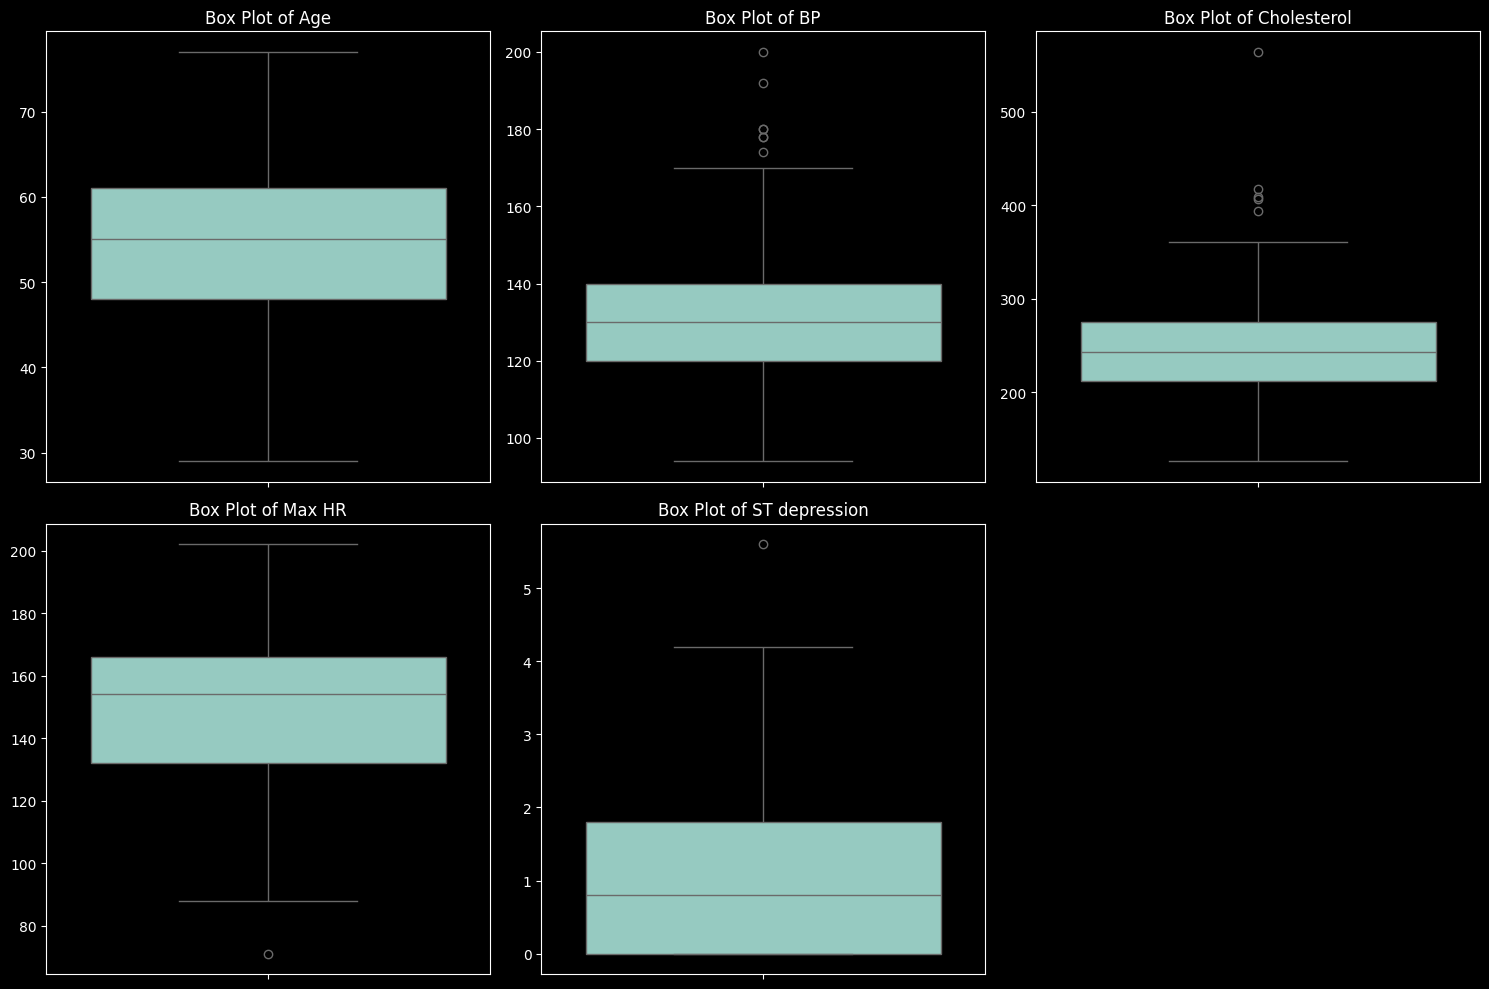

In [169]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Identifying Outlier Indices using IQR**

In [170]:
outlier_indices = {}
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].index.tolist()
    outlier_indices[col] = col_outliers

    print(f"Column: {col}")
    print(f"  Number of outliers: {len(col_outliers)}")
    print(f"  Outlier indices: {col_outliers}\n")

Column: Age
  Number of outliers: 0
  Outlier indices: []

Column: BP
  Number of outliers: 7
  Outlier indices: [58, 87, 110, 117, 153, 168, 174]

Column: Cholesterol
  Number of outliers: 5
  Outlier indices: [1, 9, 52, 190, 197]

Column: Max HR
  Number of outliers: 1
  Outlier indices: [101]

Column: ST depression
  Number of outliers: 1
  Outlier indices: [165]



**Capping Outliers using IQR**

In [171]:
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in X_train
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Cap outliers in X_test using bounds from X_train
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully in X_train and X_test.")

display(X_train.head())
display(X_test.head())

Outliers capped successfully in X_train and X_test.


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,70.0,0,4,130,322.0,0,2,109,0,2.4,...,3,3,0,1,0,0,0,1,0,0
1,67.0,1,3,115,369.5,0,2,160,0,1.6,...,0,7,0,0,1,0,0,0,1,0
2,57.0,0,2,124,261.0,0,0,141,0,0.3,...,0,7,0,0,1,0,0,1,0,0
3,64.0,0,4,128,263.0,0,0,105,1,0.2,...,1,7,0,0,0,1,0,1,0,0
4,74.0,1,2,120,269.0,0,2,121,1,0.2,...,1,3,0,0,1,0,0,0,1,0


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,41.0,1,2,130,204,0,2,172,0,1.4,...,0,3,0,0,0,1,0,1,0,0
1,63.0,1,3,135,252,0,2,172,0,0.0,...,0,3,0,0,1,0,0,0,1,0
2,51.0,0,3,94,227,0,0,154,1,0.0,...,1,7,0,0,0,1,0,1,0,0
3,54.0,0,3,120,258,0,2,147,0,0.4,...,0,7,0,0,0,1,0,0,1,0
4,44.0,0,2,120,220,0,0,170,0,0.0,...,0,3,0,0,1,0,1,0,0,0


**Visualizing Outliers after Capping with Box Plots**

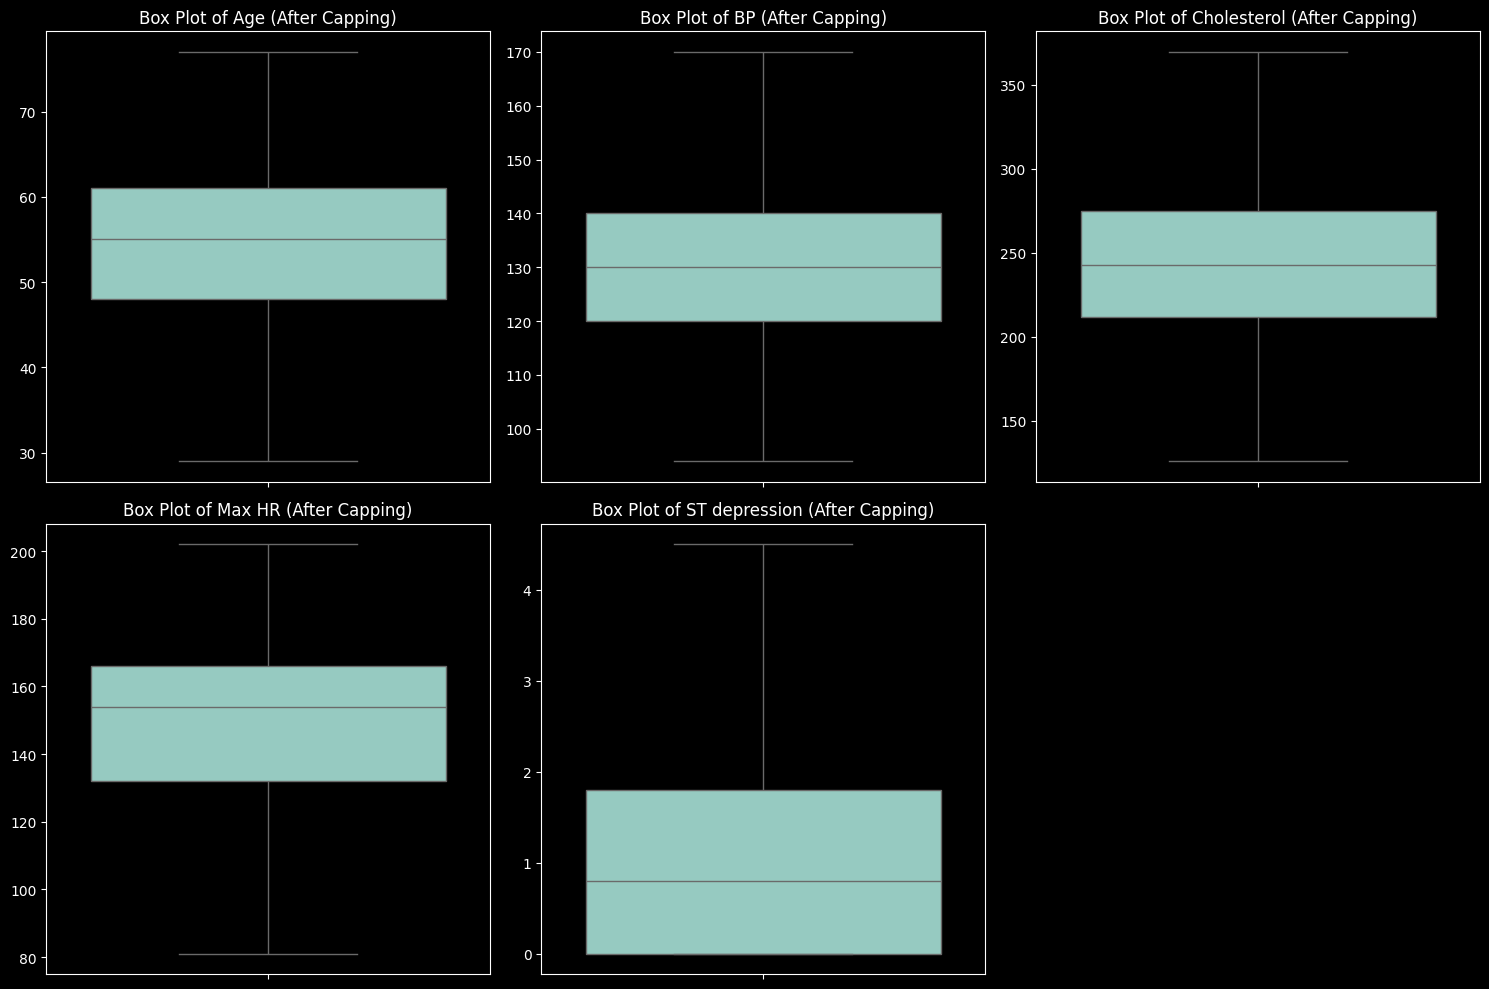

In [172]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Scaling Numerical Features**

In [173]:


scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,Number of vessels fluro,Thallium,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children
0,1.685249,0,4,-0.017245,1.642873,0,2,-1.704092,0,1.252522,...,3,3,0,1,0,0,0,1,0,0
1,1.357846,1,3,-0.908676,2.676621,0,2,0.452977,0,0.526140,...,0,7,0,0,1,0,0,0,1,0
2,0.266502,0,2,-0.373818,0.315322,0,0,-0.350637,0,-0.654230,...,0,7,0,0,1,0,0,1,0,0
3,1.030443,0,4,-0.136102,0.358849,0,0,-1.873274,1,-0.745027,...,1,7,0,0,0,1,0,1,0,0
4,2.121786,1,2,-0.611533,0.489427,0,2,-1.196546,1,-0.745027,...,1,3,0,0,1,0,0,0,1,0


**SVM without using a grid search**

In [180]:
plt.style.use('dark_background')

# just picking randomly here until we do a grid search
svm_model = SVC(kernel='rbf', C=0.1, random_state=42)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_of_svm = accuracy_score(y_test, y_pred_svm)

print("--- SVM Model Evaluation ---")
print("Accuracy: ", f"{accuracy_of_svm:.3f}")

--- SVM Model Evaluation ---
Accuracy:  0.804


**SVM Confusion Matrix Without Using Grid Search**

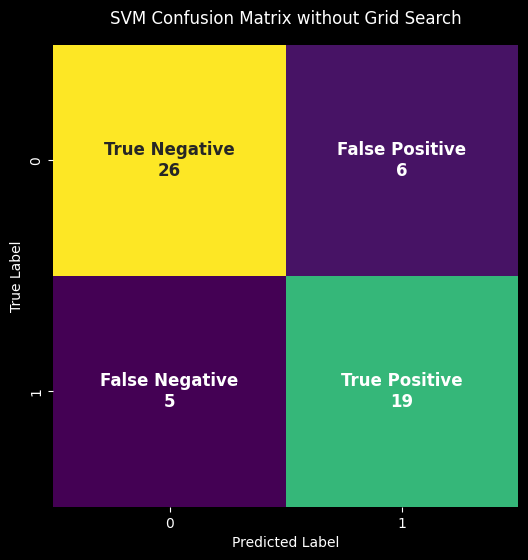

In [179]:
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False, 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_, 
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix without Grid Search", pad=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**SVM Grid Search**

In [176]:
# we use an algorithm called grid search to find the optimal values for our hyperparameters 
# instead of just picking them randomly like i did above

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] # added gamma to give the rbf/poly kernels more tuning options
}

svm_base = SVC(random_state=42)

svm_grid = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# cv = 5 means we are doing 5-fold cross-validation
# n_jobs=-1 means we are using all available CPU cores to speed up the search process



**SVM using a Grid Search**

In [181]:
svm_grid.fit(X_train, y_train)
y_pred_grid_search_svm = svm_grid.predict(X_test)
accuracy_of_grid_search_svm = accuracy_score(y_test, y_pred_grid_search_svm)
best_svm = svm_grid.best_estimator_

print("--- SVM Model Evaluation ---")
print("Best Hyperparameters Found:", svm_grid.best_params_)
print("Best Cross-Validation Accuracy: ", f"{accuracy_of_grid_search_svm:.3f}")

--- SVM Model Evaluation ---
Best Hyperparameters Found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy:  0.839


**SVM Confusion Matrix using Grid Serach**

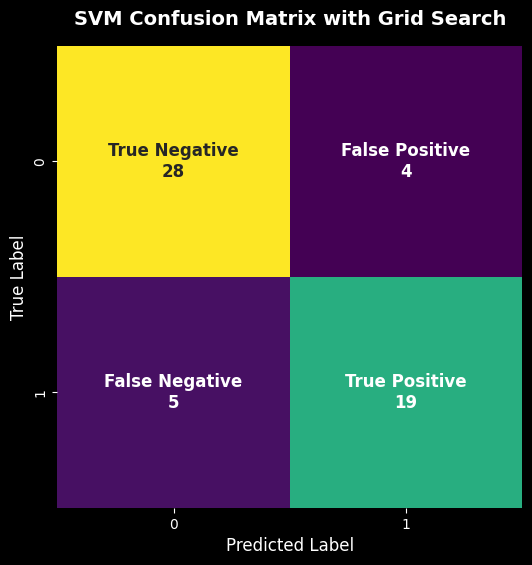

In [178]:
plt.style.use('dark_background')

cm = confusion_matrix(y_test, y_pred_grid_search_svm, labels=best_svm.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False, 
            xticklabels=best_svm.classes_, yticklabels=best_svm.classes_, 
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix with Grid Search", pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()